# Notebook de Análisis de Google Play Store (COMENTARIO PARA ESTUDIAR)
Este notebook muestra un pipeline completo de carga, limpieza, validación y análisis con comentarios detallados para reclutadores y para estudiar.

## 1) Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set(style='whitegrid')

## 2) Cargar y explorar datos

In [2]:
data_path = '../DATA/googleplaystore.csv'
df = pd.read_csv(data_path)
print('Filas', len(df), 'Columnas', len(df.columns))
display(df.head())
display(df.info())
display(df.describe(include='all').transpose())
display(df.isna().sum())

Filas 10841 Columnas 13


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,10841,9660,ROBLOX,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,10841,34,FAMILY,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9367.0,NaN,NaN,NaN,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0
Reviews,10841,6002,0,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,10841,462,Varies with device,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installs,10841,22,"1,000,000+",1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10840,3,Free,10039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,10841,93,0,10040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content Rating,10840,6,Everyone,8714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,10841,120,Tools,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

## 3) Funciones de validación de calidad (COMENTARIO PARA ESTUDIAR)

In [3]:
def quality_report(df):
    report = {}
    report['total_rows'] = len(df)
    report['missing_pct'] = (df.isna().mean() * 100).round(2).to_dict()
    report['duplicate_rows'] = int(df.duplicated().sum())
    report['unique_app'] = int(df['App'].nunique(dropna=True))
    return report

def convert_size_to_bytes(size):
    if pd.isna(size):
        return np.nan
    s = str(size).strip()
    if s == '' or s.lower() == 'varies with device':
        return np.nan
    s = s.replace(',', '').replace(' ', '')
    if s.endswith('M') or s.endswith('m'):
        return float(s[:-1]) * 1_000_000
    if s.endswith('K') or s.endswith('k'):
        return float(s[:-1]) * 1_000
    try:
        return float(s)
    except:
        return np.nan

## 4) Limpieza de datos con validación

In [4]:
clean = df.copy()
clean.columns = [c.strip().replace(' ', '_') for c in clean.columns]
clean['rating'] = pd.to_numeric(clean['Rating'], errors='coerce')
clean['reviews'] = pd.to_numeric(clean['Reviews'], errors='coerce')
clean['size_bytes'] = clean['Size'].apply(convert_size_to_bytes)
mean_size = clean['size_bytes'].mean(skipna=True)
clean['size_bytes'] = clean['size_bytes'].fillna(mean_size)
clean['installs'] = pd.to_numeric(clean['Installs'].astype(str).str.replace('[+,]', '', regex=True), errors='coerce')
clean['price'] = pd.to_numeric(clean['Price'].astype(str).str.replace('[$]', '', regex=True).replace('Free', '0'), errors='coerce').fillna(0.0)
clean['content_rating_num'] = clean['Content_Rating'].map({'Everyone':1,'Everyone 10+':2,'Teen':3,'Mature 17+':4,'Adults only 18+':5,'Unrated':0}).fillna(0).astype(int)
clean['type_num'] = clean['Type'].map({'Free':0,'Paid':1}).fillna(0).astype(int)
clean['last_updated'] = pd.to_datetime(clean['Last_Updated'], errors='coerce')
clean['android_version_num'] = clean['Android_Ver'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
clean['is_valid'] = (~clean['App'].isna()) & (clean['App'].astype(str).str.strip() != '') & (clean['App'].astype(str).str.strip().str.lower() != 'app')
clean = clean[clean['is_valid']]
clean = clean.drop_duplicates(subset=['App', 'Category'])
display(quality_report(clean))

{'total_rows': 9745,
 'missing_pct': {'App': 0.0,
  'Category': 0.0,
  'Rating': 15.02,
  'Reviews': 0.0,
  'Size': 0.0,
  'Installs': 0.0,
  'Type': 0.01,
  'Price': 0.0,
  'Content_Rating': 0.01,
  'Genres': 0.0,
  'Last_Updated': 0.0,
  'Current_Ver': 0.08,
  'Android_Ver': 0.03,
  'rating': 15.02,
  'reviews': 0.01,
  'size_bytes': 0.0,
  'installs': 0.01,
  'price': 0.0,
  'content_rating_num': 0.0,
  'type_num': 0.0,
  'last_updated': 0.01,
  'android_version_num': 10.35,
  'is_valid': 0.0},
 'duplicate_rows': 0,
 'unique_app': 9660}

## 5) Análisis exploratorio

,rating,size_bytes,installs,type_num,content_rating_num
count,8281.000000,9.745000e+03,9.744000e+03,9745.000000,9745.000000
mean,4.176875,2.065125e+07,8.203883e+06,0.077783,1.373320
std,0.558980,2.048937e+07,5.527899e+07,0.267844,0.835006
min,1.000000,8.500000e+03,0.000000e+00,0.000000,0.000000
25%,4.000000,5.300000e+06,1.000000e+03,0.000000,1.000000
50%,4.300000,1.600000e+07,1.000000e+05,0.000000,1.000000
75%,4.500000,2.500000e+07,1.000000e+06,0.000000,1.000000
max,19.000000,1.000000e+08,1.000000e+09,1.000000,5.000000


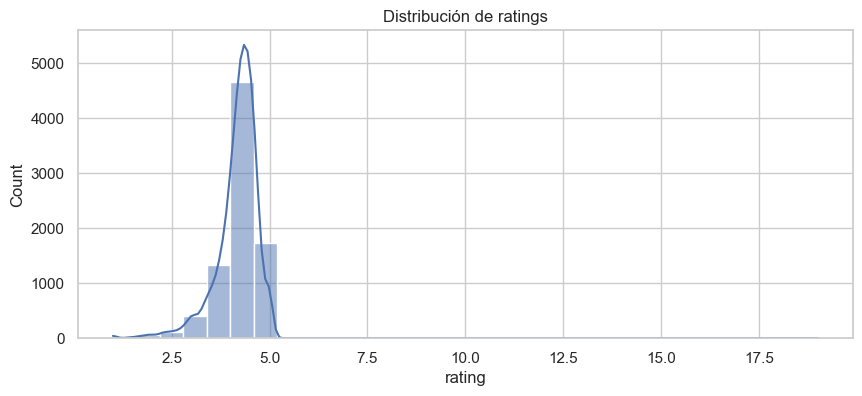

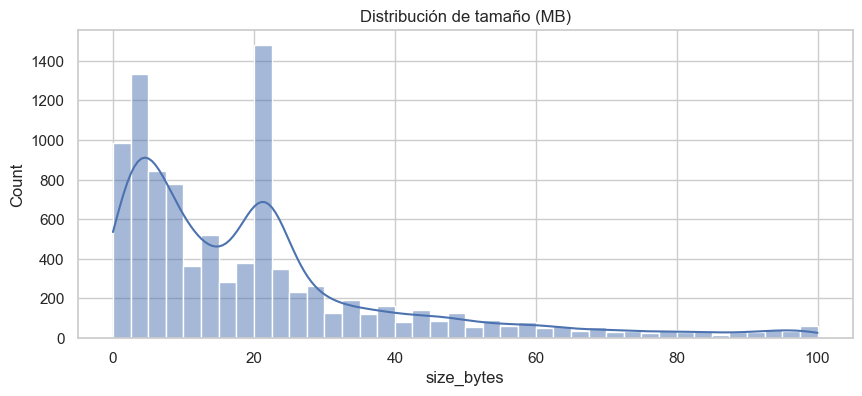

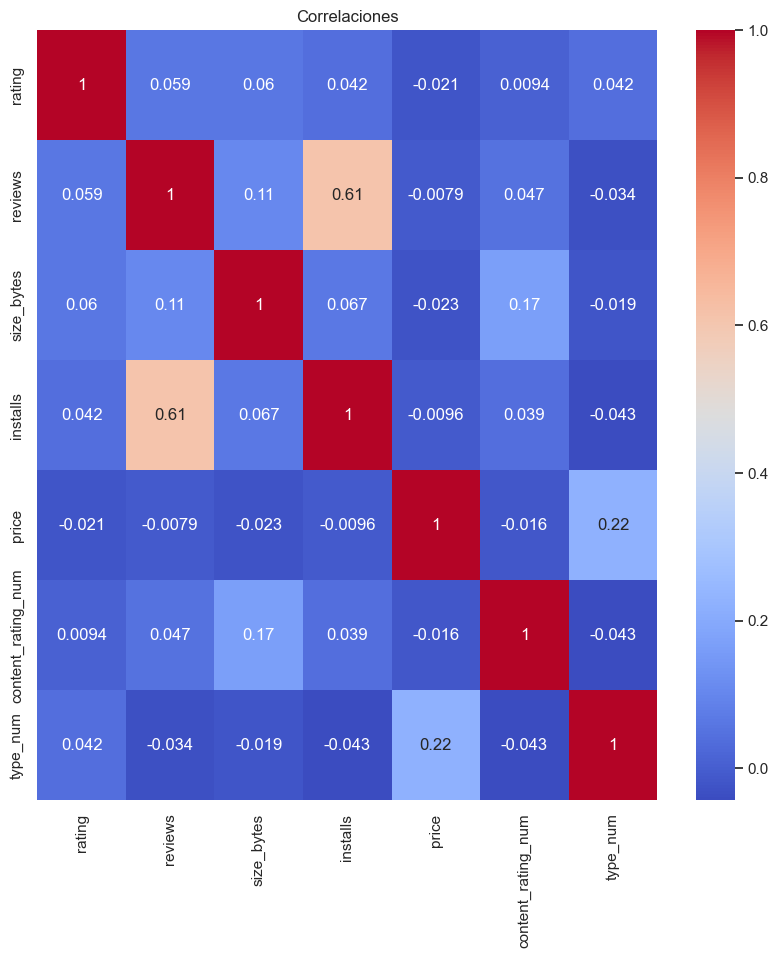

In [5]:
display(clean[['rating','size_bytes','installs','type_num','content_rating_num']].describe())
plt.figure(figsize=(10,4))
sns.histplot(clean['rating'].dropna(), bins=30, kde=True)
plt.title('Distribución de ratings')
plt.show()
plt.figure(figsize=(10,4))
sns.histplot(clean['size_bytes']/1e6, bins=40, kde=True)
plt.title('Distribución de tamaño (MB)')
plt.show()
plt.figure(figsize=(10,10))
sns.heatmap(clean[['rating','reviews','size_bytes','installs','price','content_rating_num','type_num']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlaciones')
plt.show()

## 6) Ejemplo de modelo y métricas
Este paso muestra un modelo simple para validar que los datos limpios pueden usarse para análisis predictivo.

In [6]:
model_data = clean.dropna(subset=['rating','size_bytes','installs','content_rating_num','type_num'])
X = model_data[['size_bytes','installs','content_rating_num','type_num']]
y = model_data['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

RMSE: 0.5501989637141321
R2: 0.006841797960348672


## 7) Comentarios para estudiar (proyecto para reclutadores)

- Este notebook documenta cada paso con comentarios y métricas de calidad.
- Se muestra: carga, limpieza de columnas con reglas, validación de calidad y análisis exploratorio.
- Para reclutadores: el enfoque muestra gobernanza, reproducibilidad y control de calidad.